# Régression linéaire simple

## Importation des bibliothèques nécessaires

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.graphics.gofplots import qqplot

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

## Analyse exploratoire des données

In [2]:
trainData = pd.read_csv('Data/train.csv')
trainData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [3]:
#afficher les 5 premières lignes du dataset
print(trainData.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [4]:
trainData.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


# Sur conseil de Gemini, appliquer le log sur le prix

## Checker quand même la distribution du prix

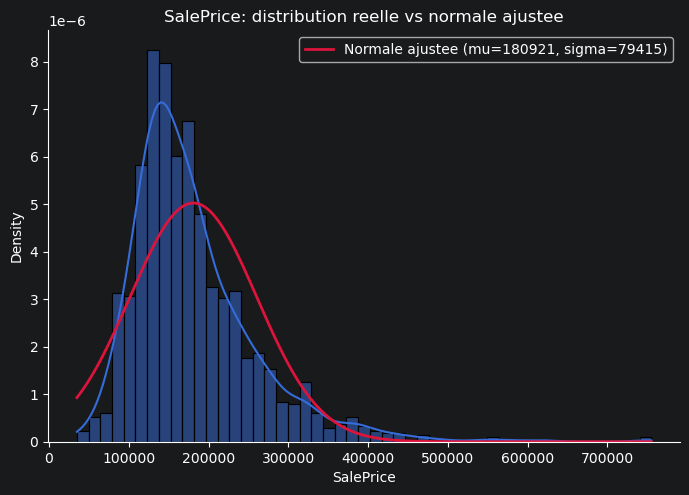

In [5]:
sale_price_raw = trainData['SalePrice'].dropna()
mu, sigma = stats.norm.fit(sale_price_raw)

# Histogramme/KDE des prix + courbe normale ajustée pour comparer visuellement
g = sns.displot(sale_price_raw, kde=True, stat='density', height=5, aspect=1.4)
x = np.linspace(sale_price_raw.min(), sale_price_raw.max(), 300)
g.ax.plot(x, stats.norm.pdf(x, mu, sigma), color='crimson', lw=2,
		  label=f'Normale ajustee (mu={mu:.0f}, sigma={sigma:.0f})')
g.ax.set_title('SalePrice: distribution reelle vs normale ajustee')
g.ax.legend()
plt.show()

## On voit que c'est pas top, 2ème check avec un QQ plot

The assocated p-value is : 3.2061412312021656e-33
With a threshold α = 0.05, we reject the null hypothesis


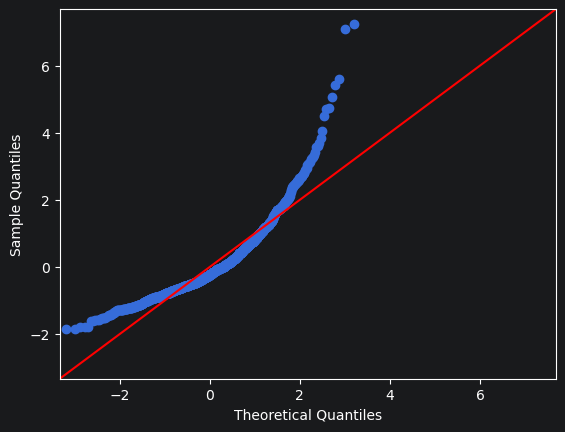

In [6]:
# Shapiro-Wilk Test for normality together with the Q-Q plot
alpha = 0.05
W, p = stats.shapiro(sale_price_raw)

print('The assocated p-value is : ' + str(p))

if p < alpha :
    print('With a threshold α = ' + str(alpha) + ', we reject the null hypothesis')
else :
    print('With a threshold α = ' + str(alpha) + ', we fail to reject the null hypothesis')

qqplot(sale_price_raw, dist = stats.distributions.norm, fit = True, line = '45')
plt.show()

## On voit que c'est pas du tout distribué normalement, on va appliquer le log sur le prix

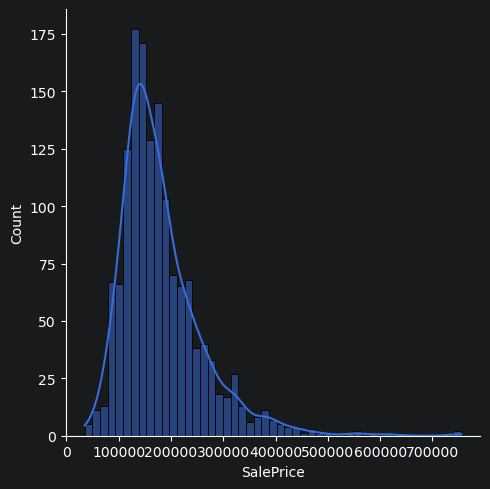

In [7]:
sale_price_log = np.log1p(sale_price_raw)

# Exploration sur la variable brute (on la garde intacte)
sns.displot(sale_price_raw, kde=True)
plt.show()

# 2) Transformation pour le modèle
y = sale_price_log

## On refait un check avec les deux graphiques

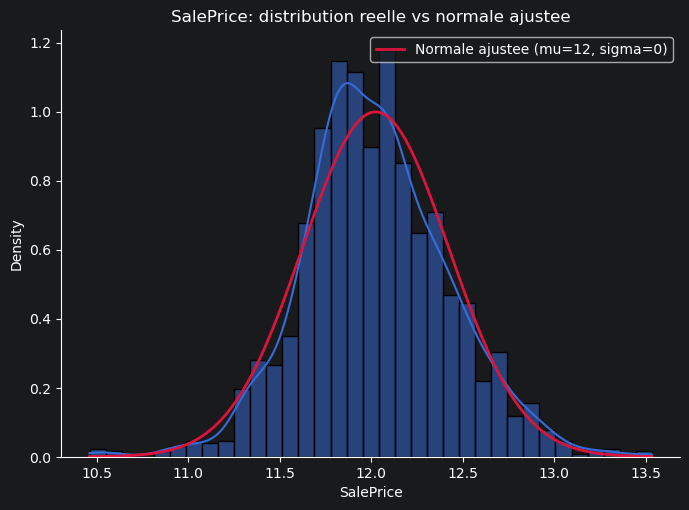

In [8]:
sale_price_log = y
mu, sigma = stats.norm.fit(sale_price_log)

# Histogramme/KDE des prix + courbe normale ajustée pour comparer visuellement
g = sns.displot(sale_price_log, kde=True, stat='density', height=5, aspect=1.4)
x = np.linspace(sale_price_log.min(), sale_price_log.max(), 300)
g.ax.plot(x, stats.norm.pdf(x, mu, sigma), color='crimson', lw=2,
		  label=f'Normale ajustee (mu={mu:.0f}, sigma={sigma:.0f})')
g.ax.set_title('SalePrice: distribution reelle vs normale ajustee')
g.ax.legend()
plt.show()

The assocated p-value is : 1.149074421908965e-07
With a threshold α = 0.05, we reject the null hypothesis


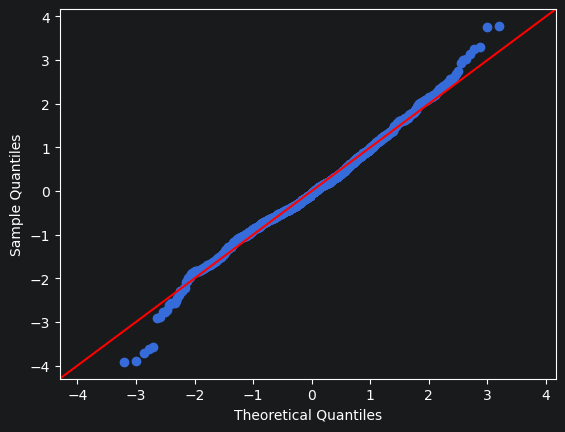

In [9]:
# Shapiro-Wilk Test for normality together with the Q-Q plot
alpha = 0.05
W, p = stats.shapiro(sale_price_log)

print('The assocated p-value is : ' + str(p))

if p < alpha :
    print('With a threshold α = ' + str(alpha) + ', we reject the null hypothesis')
else :
    print('With a threshold α = ' + str(alpha) + ', we fail to reject the null hypothesis')

qqplot(sale_price_log, dist = stats.distributions.norm, fit = True, line = '45')
plt.show()

# Split et préparation des données

In [10]:
qualitative = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
               'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
               'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
               'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
               'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
               'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
               'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageFinish',
               'GarageCars', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
               'SaleType', 'SaleCondition', 'MoSold']

quantitative = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea', 'BsmtFinSF1',
                'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
                'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch',
                'PoolArea', 'MiscVal']

date = ['YearBuilt', 'YearRemodAdd', 'YrSold', 'GarageYrBlt']

## Check des valeurs manquantes (grosse copie du cheat sheet du prof)

In [11]:
def plot_missing(trainData):
    missing = trainData.isnull().sum()
    missing = missing[missing > 0]

    if missing.empty:
        print('No missing values')
    else:
        missing.sort_values(inplace=True)
        missing.plot.bar()

        plt.show()

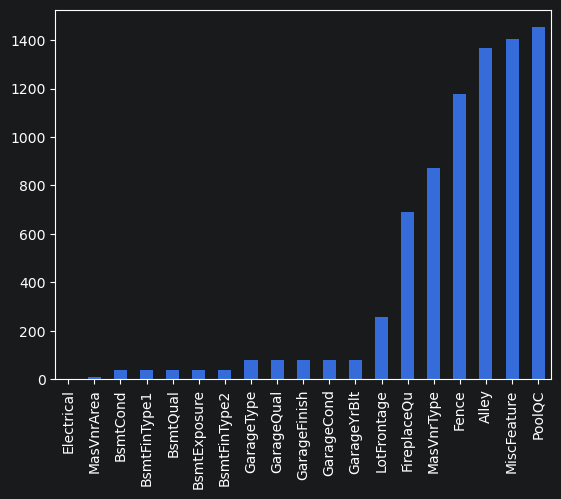

In [12]:
plot_missing(trainData)

## Pareil mais avec le code de Gemini pour Flex

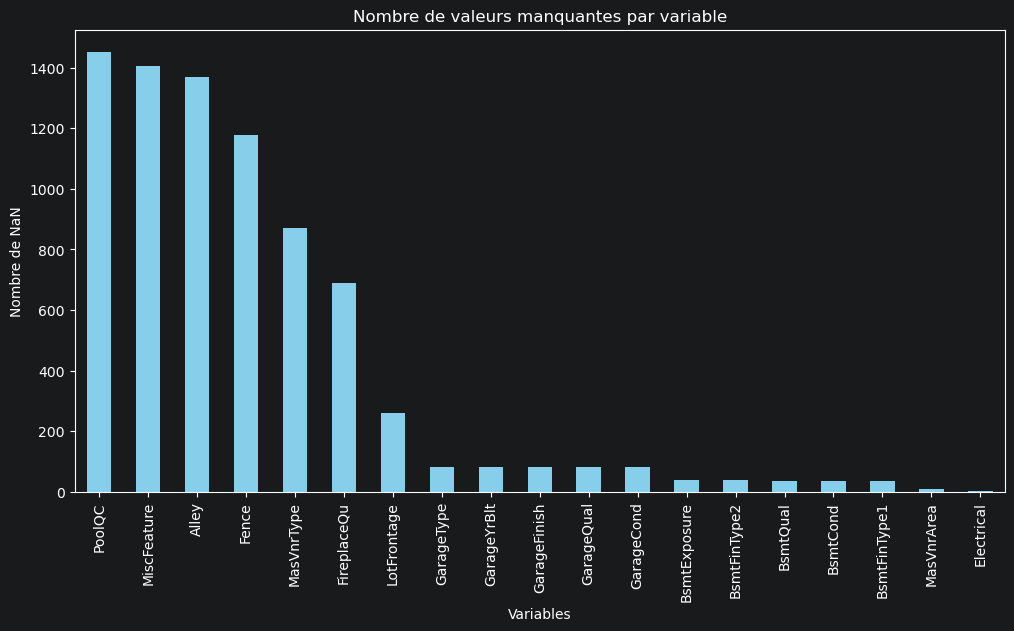

              Total  Pourcentage
PoolQC         1453    99.520548
MiscFeature    1406    96.301370
Alley          1369    93.767123
Fence          1179    80.753425
MasVnrType      872    59.726027
FireplaceQu     690    47.260274
LotFrontage     259    17.739726
GarageType       81     5.547945
GarageYrBlt      81     5.547945
GarageFinish     81     5.547945
GarageQual       81     5.547945
GarageCond       81     5.547945
BsmtExposure     38     2.602740
BsmtFinType2     38     2.602740
BsmtQual         37     2.534247
BsmtCond         37     2.534247
BsmtFinType1     37     2.534247
MasVnrArea        8     0.547945
Electrical        1     0.068493


In [13]:
def plot_missing(df):
    # Calcul du nombre et du pourcentage
    total = df.isnull().sum()
    percent = (df.isnull().sum() / df.isnull().count() * 100)

    # On regroupe et on ne garde que ce qui est > 0
    missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Pourcentage'])
    missing_data = missing_data[missing_data['Total'] > 0].sort_values(by='Total', ascending=False)

    if missing_data.empty:
        print('✅ Aucune valeur manquante !')
    else:
        # Affichage du graphique
        plt.figure(figsize=(12, 6))
        missing_data['Total'].plot.bar(color='skyblue')
        plt.title('Nombre de valeurs manquantes par variable')
        plt.xlabel('Variables')
        plt.ylabel('Nombre de NaN')
        plt.show()

        # On affiche aussi le tableau pour voir les pourcentages précis
        print(missing_data)

# Utilisation
plot_missing(trainData)

## Constat :

Il y a des colonnes ou l'absence de données veut enfait dire, absence de l'object. Par ex pour PoolQC, si c'est NaN, c'est que la maison n'a pas de piscine. Je liste comme suit :

#### Catégorie A : Les "NA" qui veulent dire "N'existe pas"
- PoolQC
- MiscFeature
- Alley
- Fence
- FireplaceQu
- GarageType
- GarageFinish
- GarageQual
- GarageCond
- BsmtExposure
- BsmtFinType2
- BsmtQual
- BsmtCond
- BsmtFinType1

⇾ **Action** : Remplacer par la chaîne de caractères "None" (pour le texte) ou 0 (pour le numérique).


#### Catégorie B : Les "NA" qui veulent dire "Données manquantes"
- LotFrontage (17%)
- MasVnrArea (0.5%)
- Electrical (0.06%)

⇾ **Action** : Utiliser la médiane ou le mode via ton Pipeline automatique.

## Fix des catégories A

In [14]:
# Liste des colonnes où NA signifie "Néant"
cols_to_fix_none = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
                    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                    'BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1',
                    'MasVnrType']

# On remplace par "None" manuellement
for col in cols_to_fix_none:
    trainData[col] = trainData[col].fillna("None")

# Pour GarageYrBlt (numérique), on peut mettre 0 ou la date de construction de la maison
trainData['GarageYrBlt'] = trainData['GarageYrBlt'].fillna(0)

## Traitement des dates
Par ex : Calcul des ages

In [15]:
# 1. Calcul des âges au moment de la vente
trainData['AgeMaison'] = trainData['YrSold'] - trainData['YearBuilt']
trainData['AgeRemod'] = trainData['YrSold'] - trainData['YearRemodAdd']

# Pour le garage, attention : si pas de garage, on a mis 0 plus tôt. 
# On peut simplifier en disant : si pas de garage, l'âge est celui de la maison.
trainData['AgeGarage'] = trainData['YrSold'] - trainData['GarageYrBlt']
trainData.loc[trainData['GarageYrBlt'] == 0, 'AgeGarage'] = trainData['AgeMaison']

# 2. On nettoie les éventuels chiffres négatifs
# (parfois une vente est enregistrée juste avant la fin des travaux)
trainData['AgeRemod'] = trainData['AgeRemod'].apply(lambda x: x if x > 0 else 0)

# 3. MISE À JOUR DE TES LISTES
# On ajoute les nouveaux et on enlève les anciens
quantitative.extend(['AgeMaison', 'AgeRemod', 'AgeGarage'])

# On retire les colonnes de dates originales pour ne pas faire doublon
colonnes_dates_a_virer = ['YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'YrSold']
quantitative = [col for col in quantitative if col not in colonnes_dates_a_virer]

## PRÉPARATION DE X ET Y

In [16]:
# On garde la cible déjà log-transformée définie plus haut
y = sale_price_log
# On retire l'ID et les cibles du set de features
X = trainData.drop(['Id', 'SalePrice'], axis=1)

## LE PIPELINE (GÈRE LA CATÉGORIE B AUTOMATIQUEMENT)

In [17]:
# Prétraitement pour les colonnes numériques (quantitative)
# C'est ICI que LotFrontage est traité (SimpleImputer)
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Prétraitement pour les colonnes textuelles (qualitative)
# C'est ICI que Electrical est traité
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# On assemble le tout
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, quantitative),
        ('cat', categorical_transformer, qualitative)
    ])

# On ajoute le modèle à la fin du Pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

## CROSS-VALIDATION

In [18]:
# Le split se fait ici (cv=5)
scores = cross_val_score(full_pipeline, X, y, cv=5, scoring='neg_root_mean_squared_error')

rmse_cv = -scores.mean()
print(f"✅ Ton score Baseline (RMSE moyen) : {rmse_cv:.4f}")

✅ Ton score Baseline (RMSE moyen) : 0.1623


# On passe au test data

## Préparation du test dataset

In [21]:
# Charger le fichier de test Kaggle
test_data = pd.read_csv('Data/test.csv')
test_ids = test_data['Id'] # On garde les IDs pour la soumission

# --- MÊME NETTOYAGE MANUEL QUE POUR LE TRAIN ---
for col in cols_to_fix_none:
    test_data[col] = test_data[col].fillna("None")

test_data['GarageYrBlt'] = test_data['GarageYrBlt'].fillna(0)

# --- MÊME FEATURE ENGINEERING (DATES) ---
test_data['AgeMaison'] = test_data['YrSold'] - test_data['YearBuilt']
test_data['AgeRemod'] = test_data['YrSold'] - test_data['YearRemodAdd']
test_data['AgeGarage'] = test_data['YrSold'] - test_data['GarageYrBlt']
test_data.loc[test_data['GarageYrBlt'] == 0, 'AgeGarage'] = test_data['AgeMaison']

# On nettoie les âges négatifs potentiels (bug fréquent dans les données)
test_data['AgeRemod'] = test_data['AgeRemod'].apply(lambda x: x if x > 0 else 0)

# On ne garde que les colonnes que le modèle connaît
X_test_final = test_data[quantitative + qualitative]

## Entraînement Final et Prédiction

In [22]:
# 1. Entraîner le pipeline sur TOUTES les données d'entraînement
full_pipeline.fit(X, y) # Rappel : y est déjà en log1p

# 2. Prédire les prix du fichier test (le résultat sera en Log)
preds_log = full_pipeline.predict(X_test_final)

# 3. L'étape CRUCIALE : Inverser le Log
# Kaggle veut des dollars, pas des logarithmes !
# L'inverse de log(1+x) est exp(x)-1
preds_final = np.expm1(preds_log)

## Créer le fichier de soumission

In [24]:
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': preds_final
})

submission.to_csv('M0_alain.csv', index=False)
print("Fichier prêt pour Kaggle !")

Fichier prêt pour Kaggle !
